### Middleware

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:

Tracking agent behavior with logging, analytics, and debugging.

Transforming prompts, tool selection, and output formatting.

Adding retries, fallbacks, and early termination logic.

Applying rate limits, guardrails, and PII detection.

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] =  os.getenv("GROQ_API_KEY")

### Summarization MiddleWare

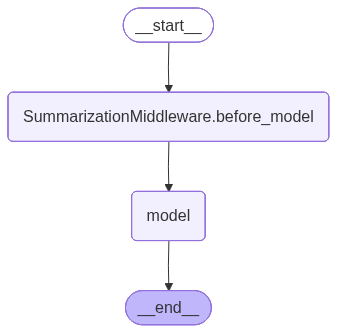

In [4]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

## agent with message based summarization

agent=create_agent(
    model="groq:llama-3.1-8b-instant", # <-- Added "groq:" prefix
    system_prompt="You are a helpful assistant.",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:llama-3.1-8b-instant", # <-- Added "groq:" prefix
            trigger=("messages",10),
            keep=("messages",4)
        )
    ]
)

agent

In [6]:
## thread id
config={"configurable":{"thread_id":"test1"}}

In [7]:
# Alternative test data
questions = [
    "What is 2+2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?",
]

for q in questions:
    response=agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")


Messages: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='7c951904-c34a-45f3-9eb7-fd5f2751c9e5'), AIMessage(content='The answer is 4.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 7, 'prompt_tokens': 48, 'total_tokens': 55, 'completion_time': 0.013328759, 'completion_tokens_details': None, 'prompt_time': 0.002379957, 'prompt_tokens_details': None, 'queue_time': 0.045369203, 'total_time': 0.015708716}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_ff2b098aaf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c7c65-cbcf-7232-9248-7379040b4317-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 48, 'output_tokens': 7, 'total_tokens': 55})]}
Messages: 2
Messages: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='7c951904-c34a-45f3-9eb7-fd5f2751c9e5'), AIM

### Token Size

In [9]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""


agent=create_agent(
    model="groq:llama-3.1-8b-instant",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:llama-3.1-8b-instant",
            trigger=("tokens",550),
            keep=("tokens",200),
        ),
    ]
)

config = {"configurable": {"thread_id": "test-1"}}

# Token counter (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4  # 4 chars ≈ 1 token

In [11]:
# Run test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )
    
    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~234 tokens, 6 messages
[HumanMessage(content="Here is a summary of the conversation to date:\n\n## SESSION INTENT\nFind hotels in Paris.\n\n## SUMMARY\nThe primary goal is to locate hotels in Paris. Research and provide hotel options in Paris. Three hotel options have been provided: Grand Hotel (5-star, $350/night), City Inn (4-star, $180/night), and Budget Stay (3-star, $75/night). The AI has called the 'search_hotels' tool twice to retrieve hotel options in Paris.\n\n## ARTIFACTS\nNone\n\n## NEXT STEPS\nProvide more detailed information about the hotel options, such as reviews and availability.", additional_kwargs={'lc_source': 'summarization'}, response_metadata={}, id='cb5c2fa7-5c48-4503-b2a2-c4c20a6c85c9'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'cye0m59at', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 533, 'total_tokens': 5